# Rome Alésia

## Importations

In [1]:
# LES ALGORITHMES
from QLearning import *
from DQN import *
from PPO import *
import time
import random
from stable_baselines3.common.env_checker import check_env

from ray.rllib.algorithms.dqn import DQNConfig
from ray.rllib.connectors.env_to_module import FlattenObservations
from pathlib import Path
from ray.rllib.core.rl_module import RLModule


# POUR AFFICHAGE
import matplotlib.pyplot as plt
import seaborn as sns
from helperPlot import *

# POUR ENVIRONNEMENT
import gymnasium
from gymnasium import spaces
from gymnasium.envs.toy_text.frozen_lake import generate_random_map

## Environnement

In [50]:
class RomeAlesiaEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaEnv, self).__init__()
        nbUnits = options['nbUnits']
        nbSteps = options['nbSteps']

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits
        
        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = random.randint(1, self.alesiaUnits+1)
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


In [16]:
class RomeAlesiaPlayerEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaPlayerEnv, self).__init__()
        nbUnits = options['nbUnits']
        nbSteps = options['nbSteps']

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits
        
        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = int(input("Combiens d'unité ? : "))
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


In [22]:
class RomeAlesiaStrongEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaStrongEnv, self).__init__()
        nbUnits = 50
        nbSteps = 2

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits
        
        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = 0

        # État 1 (adjacent à Rome)
        if self.battleFront == 1 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                alesiaAction = self.alesiaUnits
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                temp = np.random.randint(0, 2)
                if temp == 0 : # 50%
                    alesiaAction = self.romeUnits
                else : # 50%
                    alesiaAction = 1
            # Egalite
            else :
                alesiaAction = np.random.randint(self.alesiaUnits-4, self.alesiaUnits-2 + 1)


        # État 2
        if self.battleFront == 2 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                alesiaAction = np.random.randint(self.alesiaUnits - self.romeUnits - 2, self.alesiaUnits - self.romeUnits + 2 + 1)
            # Sinon
            else :
                temp = np.random.randint(0, 4)
                if temp == 0 : # 25%
                    alesiaAction = np.random.randint(1, 4 +1)
                else : # 75%
                    alesiaAction = np.random.randint(6, max(6, self.alesiaUnits//3) +1)

        
        # État 3 (centre)
        if self.battleFront == 3 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                # Suravantage pour Alésia
                if self.alesiaUnits > 2*self.romeUnits :
                    alesiaAction = self.alesiaUnits // 3
                else :
                    alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits // 3)-1) +1)
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                temp = np.random.randint(0, 2)
                if temp == 0 : # 50%
                    alesiaAction = np.random.randint(2, 5 +1)
                else : # 50%
                    alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
            # Égalité
            else :
                alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits//3)-1) +1)

        # État 4
        if self.battleFront == 4 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                temp = np.random.randint(0, 4)
                if temp == 0 :
                    alesiaAction = np.random.randint(2, 5 +1)
                else :
                    alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                alesiaAction = np.random.randint(1, 4)
            # Égalité
            else :
                temp = np.random.randint(0, 2)
                if temp == 0 :
                    alesiaAction = np.random.randint(2, 5 +1)
                else :
                    alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)

        # État 5 (adjacent à Alesia)
        if self.battleFront == 5 :
            # Avantage pour Alésia
            if self.alesiaUnits > self.romeUnits :
                # Suravantage pour Alésia
                if self.alesiaUnits >= 1.5*self.romeUnits :
                    alesiaAction = self.romeUnits
                elif self.romeUnits < 15 :
                    alesiaAction = self.romeUnits
                else :
                    temp = np.random.randint(0, 2)
                    if temp == 0 :
                        alesiaAction = self.romeUnits
                    else :
                        alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
            # Avantage pour Rome
            elif self.alesiaUnits < self.romeUnits :
                alesiaAction = self.romeUnits
            # Égalité
            else :
                temp = np.random.randint(0, 2)
                if temp == 0 :
                    alesiaAction = self.romeUnits
                else :
                    alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
        
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


In [81]:
class RomeAlesiaRandomOppEnv(gymnasium.Env) :

    def __init__(self, options = None) :
        super(RomeAlesiaRandomOppEnv, self).__init__()
        nbUnits = 50
        nbSteps = 2

        
        self.nbUnits = nbUnits
        self.romeUnits = nbUnits
        self.alesiaUnits = nbUnits

        self.nbSteps = nbSteps
        self.romeLocation = 0
        self.alesiaLocation = 2 * nbSteps + 2
        self.battleFront = nbSteps + 1

        self.action_space = spaces.Discrete(nbUnits+1)
        self.observation_space = spaces.MultiDiscrete([2 * nbSteps + 3, nbUnits+1, nbUnits+1])


    def reset(self, seed = None, options = None) :
        super().reset(seed = seed)

        self.romeUnits = self.nbUnits
        self.alesiaUnits = self.nbUnits
        self.battleFront = self.nbSteps +1 

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), {}


    def step(self, romeAction) :
        alesiaAction = 0
        exploitation_proba = np.random.random()

        if exploitation_proba < 0.95 :

            # État 1 (adjacent à Rome)
            if self.battleFront == 1 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    alesiaAction = self.alesiaUnits
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    temp = np.random.randint(0, 2)
                    if temp == 0 : # 50%
                        alesiaAction = self.romeUnits
                    else : # 50%
                        alesiaAction = 1
                # Egalite
                else :
                    alesiaAction = np.random.randint(self.alesiaUnits-4, self.alesiaUnits-2 + 1)
    
    
            # État 2
            if self.battleFront == 2 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    alesiaAction = np.random.randint(self.alesiaUnits - self.romeUnits - 2, self.alesiaUnits - self.romeUnits + 2 + 1)
                # Sinon
                else :
                    temp = np.random.randint(0, 4)
                    if temp == 0 : # 25%
                        alesiaAction = np.random.randint(1, 4 +1)
                    else : # 75%
                        alesiaAction = np.random.randint(6, max(6, self.alesiaUnits//3) +1)
    
            
            # État 3 (centre)
            if self.battleFront == 3 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    # Suravantage pour Alésia
                    if self.alesiaUnits > 2*self.romeUnits :
                        alesiaAction = self.alesiaUnits // 3
                    else :
                        alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits // 3)-1) +1)
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    temp = np.random.randint(0, 2)
                    if temp == 0 : # 50%
                        alesiaAction = np.random.randint(2, 5 +1)
                    else : # 50%
                        alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
                # Égalité
                else :
                    alesiaAction = np.random.randint(2, max(2, (self.alesiaUnits//3)-1) +1)
    
            # État 4
            if self.battleFront == 4 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    temp = np.random.randint(0, 4)
                    if temp == 0 :
                        alesiaAction = np.random.randint(2, 5 +1)
                    else :
                        alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    alesiaAction = np.random.randint(1, 4)
                # Égalité
                else :
                    temp = np.random.randint(0, 2)
                    if temp == 0 :
                        alesiaAction = np.random.randint(2, 5 +1)
                    else :
                        alesiaAction = np.random.randint(6, max(6, (self.alesiaUnits//3)-1) +1)
    
            # État 5 (adjacent à Alesia)
            if self.battleFront == 5 :
                # Avantage pour Alésia
                if self.alesiaUnits > self.romeUnits :
                    # Suravantage pour Alésia
                    if self.alesiaUnits >= 1.5*self.romeUnits :
                        alesiaAction = self.romeUnits
                    elif self.romeUnits < 15 :
                        alesiaAction = self.romeUnits
                    else :
                        temp = np.random.randint(0, 2)
                        if temp == 0 :
                            alesiaAction = self.romeUnits
                        else :
                            alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
                # Avantage pour Rome
                elif self.alesiaUnits < self.romeUnits :
                    alesiaAction = self.romeUnits
                # Égalité
                else :
                    temp = np.random.randint(0, 2)
                    if temp == 0 :
                        alesiaAction = self.romeUnits
                    else :
                        alesiaAction = np.random.randint(2, max(2, self.alesiaUnits - self.romeUnits) +1)
        else :
            alesiaAction = random.randint(1, self.alesiaUnits+1)
        
        if romeAction <= 0 :
            romeAction = 1
        if alesiaAction <= 0 :
            alesiaAction = 1
        
        if romeAction > self.romeUnits :
            romeAction = self.romeUnits
        self.romeUnits -= romeAction

        if alesiaAction > self.alesiaUnits :
            alesiaAction = self.alesiaUnits
        self.alesiaUnits -= alesiaAction

        if romeAction > alesiaAction :
            self.battleFront += 1
        elif romeAction < alesiaAction :
            self.battleFront -= 1

        romeReward = 0
        done = False
        if self.battleFront == self.romeLocation :
            romeReward = -1
            done = True
        elif self.battleFront == self.alesiaLocation :
            romeReward = 1
            done = True

        if self.romeUnits == 0 and self.alesiaUnits == 0 :
            done = True

        return np.array([self.battleFront, self.romeUnits, self.alesiaUnits], dtype=np.int64), romeReward, done, False, {}


    def render(self) :
        toPrint = ""
        middlePoint = self.nbSteps + 1

        if self.battleFront != self.romeLocation :
            toPrint += "R"
        else :
            toPrint += "X"
        
        for i in range(1, self.nbSteps+1) :
            if i != self.battleFront :
                toPrint += "--|"
            else :
                toPrint += "--X"

        if self.battleFront != middlePoint :
            toPrint += "--M--"
        else :
            toPrint += "--X--"

        for i in range(1, self.nbSteps+1) :
            if i+middlePoint != self.battleFront :
                toPrint += "|--"
            else :
                toPrint += "X--"

        if self.battleFront != self.alesiaLocation :
            toPrint += "A"
        else :
            toPrint += "X"

        print(toPrint)
        print(f"Rome has {self.romeUnits} units remaining.")
        print(f"Alesia has {self.alesiaUnits} units remaining.")


### Play Against Strong Opponent

In [43]:
done = False
env = RomeAlesiaStrongEnv()
state, _ = env.reset()

while not done :
    env.render()
    romeAction = int(input("Combiens d'unité ? : "))
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  0


R--|--X--M--|--|--A
Rome has 49 units remaining.
Alesia has 46 units remaining.


Combiens d'unité ? :  2


R--X--|--M--|--|--A
Rome has 47 units remaining.
Alesia has 39 units remaining.


...

R--|--|--M--X--|--A
Rome has 7 units remaining.
Alesia has 0 units remaining.


Combiens d'unité ? :  1


R--|--|--M--|--X--A
Rome has 6 units remaining.
Alesia has 0 units remaining.


Combiens d'unité ? :  1


R--|--|--M--|--|--X
Rome has 5 units remaining.
Alesia has 0 units remaining.


### Check classic environment

In [8]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)

check_env(env)

### Get winning chances

In [54]:
def get_win_pourcent(env, model) :
    wins = 0
    for _ in range(10000) :
        state, _ = env.reset()
        done = False
        while not done :
            romeAction = get_best_action(model, state)
            state, _, done, _, _ = env.step(romeAction)
        if env.battleFront == env.alesiaLocation :
            wins += 1

    return (wins / 10000) * 100

## QLearning

### QLearning par défaut contre joueur aléatoire

Essayons le QLearning par défaut

In [56]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 10000000, useProdForReward = True, maxTimestepsProd = 100)

print("DONE")

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.
DONE


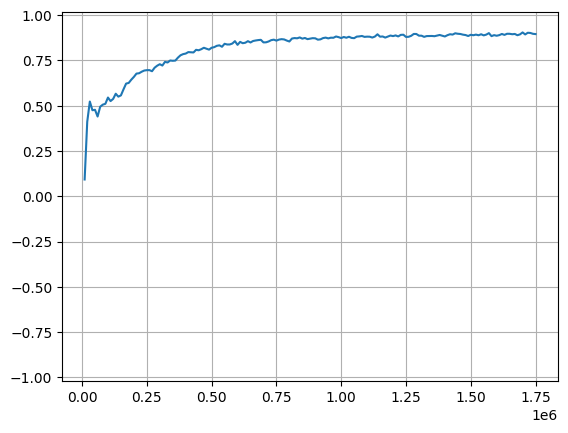

In [57]:
ordo, toPlot = mean_plot(prodReward, 10000)

plt.ylim(-1.02, 1.02)
plt.plot(ordo, toPlot)
plt.grid()
plt.show()

In [17]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(model, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  2


R--|--X--M--|--|--A
Rome has 49 units remaining.
Alesia has 48 units remaining.


Combiens d'unité ? :  2


R--|--|--X--|--|--A
Rome has 19 units remaining.
Alesia has 46 units remaining.


...

R--|--X--M--|--|--A
Rome has 0 units remaining.
Alesia has 32 units remaining.


Combiens d'unité ? :  1


R--X--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 31 units remaining.


Combiens d'unité ? :  1


X--|--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 30 units remaining.


In [58]:
env = RomeAlesiaEnv({'nbUnits' : 50, 'nbSteps' : 2})
print(f"Winning % against random opponent : {get_win_pourcent(env, model)}%")

env = RomeAlesiaStrongEnv()
print(f"Winning % against strong opponent : {get_win_pourcent(env, model)}%")

Winning % against random opponent : 91.8%
Winning % against strong opponent : 2.11%


### QLearning par défaut contre joueur expérimenté

In [24]:
env = RomeAlesiaStrongEnv()
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 10000000, useProdForReward = True, maxTimestepsProd = 100)

print("DONE")

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.
DONE


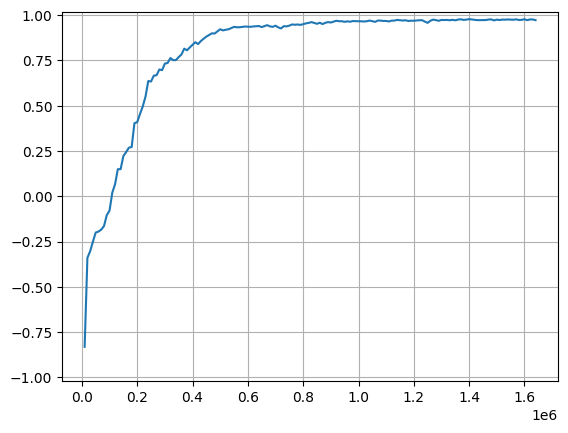

In [45]:
ordo, toPlot = mean_plot(prodReward, 10000)

plt.ylim(-1.02, 1.02)
plt.plot(ordo, toPlot)
plt.grid()
plt.show()

In [39]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(model, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  2


R--|--|--M--X--|--A
Rome has 35 units remaining.
Alesia has 48 units remaining.


Combiens d'unité ? :  2


R--|--|--M--|--X--A
Rome has 20 units remaining.
Alesia has 46 units remaining.


...

R--|--X--M--|--|--A
Rome has 0 units remaining.
Alesia has 23 units remaining.


Combiens d'unité ? :  1


R--X--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 22 units remaining.


Combiens d'unité ? :  1


X--|--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 21 units remaining.


In [55]:
env = RomeAlesiaEnv({'nbUnits' : 50, 'nbSteps' : 2})
print(f"Winning % against random opponent : {get_win_pourcent(env, model)}%")

env = RomeAlesiaStrongEnv()
print(f"Winning % against strong opponent : {get_win_pourcent(env, model)}%")

Winning % against random opponent : 55.15%
Winning % against strong opponent : 98.0%


### Save / Import and Play against model

In [99]:
npModel = np.array(model)

In [102]:
np.save("./model/model.npy", npModel)

In [103]:
importedModel = np.load("./model/model.npy")

In [104]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(importedModel, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  2


R--|--|--M--X--|--A
Rome has 35 units remaining.
Alesia has 48 units remaining.


Combiens d'unité ? :  15


R--|--|--M--X--|--A
Rome has 20 units remaining.
Alesia has 33 units remaining.


...

R--|--X--M--|--|--A
Rome has 9 units remaining.
Alesia has 14 units remaining.


Combiens d'unité ? :  5


R--X--|--M--|--|--A
Rome has 7 units remaining.
Alesia has 9 units remaining.


Combiens d'unité ? :  9


X--|--|--M--|--|--A
Rome has 0 units remaining.
Alesia has 0 units remaining.


### QLearning par défaut contre les deux joueurs aléatoirement

In [85]:
env = RomeAlesiaRandomOppEnv()
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 10000000, useProdForReward = True, maxTimestepsProd = 100)

print("DONE")

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.
DONE


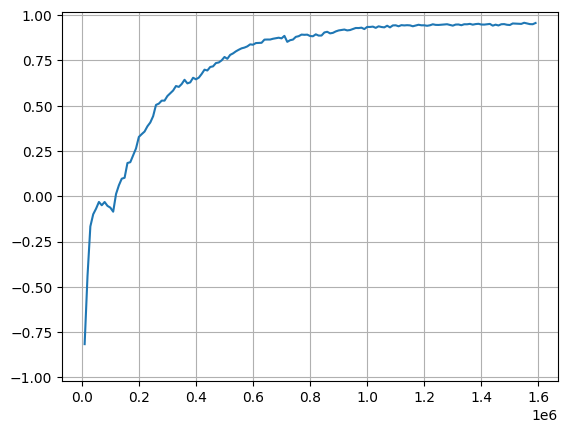

In [86]:
ordo, toPlot = mean_plot(prodReward, 10000)

plt.ylim(-1.02, 1.02)
plt.plot(ordo, toPlot)
plt.grid()
plt.show()

In [92]:
done = False
env = RomeAlesiaPlayerEnv(
    {
        'nbUnits' : 50,
        'nbSteps' : 2
    }
)
state, _ = env.reset()

while not done :
    env.render()
    romeAction = get_best_action(model, state)
    state, _, done, _, _ = env.step(romeAction)
env.render()

R--|--|--X--|--|--A
Rome has 50 units remaining.
Alesia has 50 units remaining.


Combiens d'unité ? :  16


R--|--X--M--|--|--A
Rome has 35 units remaining.
Alesia has 34 units remaining.


Combiens d'unité ? :  19


R--X--|--M--|--|--A
Rome has 25 units remaining.
Alesia has 15 units remaining.


...

R--|--|--M--X--|--A
Rome has 2 units remaining.
Alesia has 0 units remaining.


Combiens d'unité ? :  0


R--|--|--M--|--X--A
Rome has 1 units remaining.
Alesia has 0 units remaining.


Combiens d'unité ? :  0


R--|--|--M--|--|--X
Rome has 0 units remaining.
Alesia has 0 units remaining.


In [87]:
env = RomeAlesiaEnv({'nbUnits' : 50, 'nbSteps' : 2})
print(f"Winning % against random opponent : {get_win_pourcent(env, model)}%")

env = RomeAlesiaStrongEnv()
print(f"Winning % against strong opponent : {get_win_pourcent(env, model)}%")

Winning % against random opponent : 85.11999999999999%
Winning % against strong opponent : 98.36%


### QLearning paramétré

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


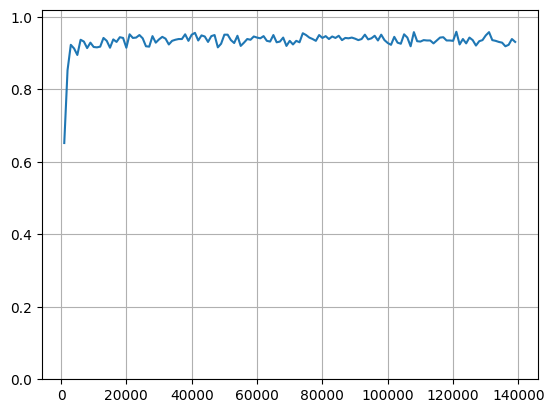

In [13]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_q_learning(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                             alpha = 0.1, eps_start = 0.05, eps_end = 0.05, eps_fraction = 0.8, gamma = 0.99
                                            )




plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

## DQN

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


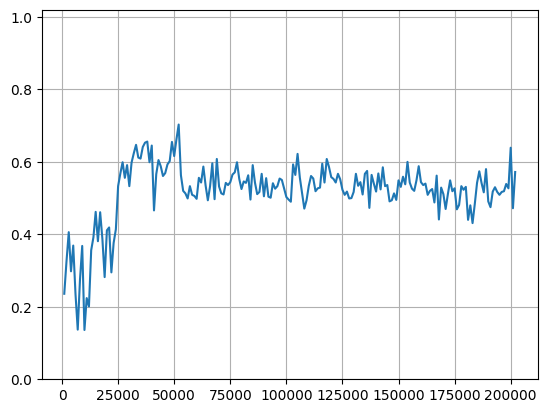

In [19]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                            )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


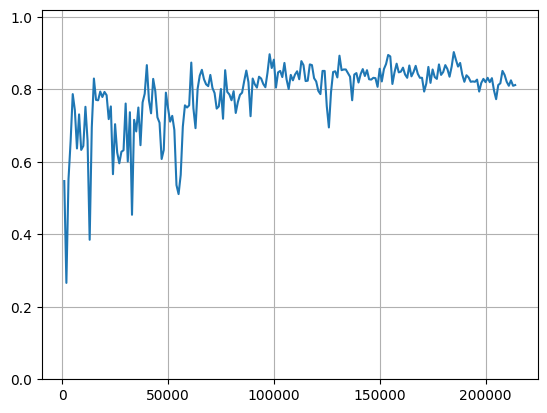

In [20]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                      learning_rate = 0.001, gamma = 0.99, buffer_size = 1000, batch_size = 32,
                                      update_freq = 50, exploration_initial_eps = 1, exploration_final_eps = 0.05,
                                      exploration_fraction = 0.8
                                     )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()

R--|--|--X--|--|--A
Rome has 20 units remaining.
Alesia has 20 units remaining.


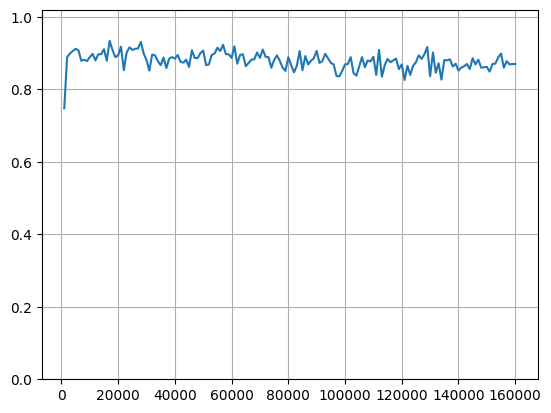

In [21]:
env = RomeAlesiaEnv(
    {
        'nbUnits' : 20,
        'nbSteps' : 2
    }
)
env.render()


model, reward, prodReward = train_dqn(env, timesteps = 1000000, useProdForReward = True, maxTimestepsProd = 100,
                                      learning_rate = 0.001, gamma = 0.99, buffer_size = 1000, batch_size = 32,
                                      update_freq = 50, exploration_initial_eps = 0.05, exploration_final_eps = 0.05,
                                      exploration_fraction = 0.8
                                     )


mean_n = 1000
somme = 0
actual_global = 0
actual_local = 0
toPlot = []
y = []
for i in range(len(prodReward)) :
    somme += prodReward[i]
    
    actual_global += 1
    actual_local += 1
    if actual_local == mean_n :
        y.append(actual_global)
        toPlot.append(somme / mean_n)
        mean = 0
        actual_local = 0
        somme = 0


plt.ylim(0, 1.02)
plt.plot(y, toPlot)
plt.grid()
plt.show()